## ASISTENTE DE CANASTA FAMILIAR

Proyecto Final<br>
Elaborado Por: Luis Manuel Morales<br>
Curso: Python for Data Analysis<br>
Corte: Diploma Ciencia de Datos e IA Aplicada_827648_DIL.DATO_2026-1A<br>
Instituto: UCU / URUGUAY

## 1. DEFINICIÓN DEL PROBLEMA

Se cuenta con un conjunto de datos vinculados a los precios de los productos que se distribuyen en Uruguay, informados SIPC (Sistema de Información de Precios al Consumidor). Se desea preparar los datos para entrenar un modelo de machine learning que pueda asistir en la compra de productos y/o canasta familiar, contemplando los siguientes atributos:
- Tipo de producto
- Época del año
- Cadena

Se espera que el modelo pueda responder a los siguientes planteamientos:
- Productos y costo de la canasta familiar
- Cadenas que ofrecen un mejor costo de la canasta familiar
- Sugerencia de productos por rango de precios


## 2. RECOPILACIÓN DE DATOS

> Dataset de [precios.uy](https://www.precios.uy/category/reporte-mensual/)

Observamos información del dataset (Precios)

| Variable  |                    Definition                    |  type   |
|:---------:|:------------------------------------------------:|:-------:|
|  Periodo  |               Preiodo (Mes y Año)                | String  |
|   Grupo   |           Grupo o famila del producto            | String  |
| Producto  |           Nombre genérico del producto           | String  |
|   Super   |        Nombre Fantasía o Establecimiento         | String  |
|  Precio   |                      Precio                      | Decimal |

> Importamos las librerías necesarias para el proyecto

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plx
import plotly.express as px
import jupyterlab
import anywidget
from pyarrow.lib import nulls
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
# extensiones
import hashlib
import locale
import datetime as dt

from streamlit import cache
from sympy import uppergamma, false, true
from sympy.physics.units import length
from sympy.sets.fancysets import Naturals




> Cargamos el Data Frame

In [2]:
# carga de datos al dataframe
df = pd.read_csv("../data/raw/p4ds_cadenas_unificadas_2025.csv")

## Paso 3: Análisis Descriptivo

Conocer las dimensiones y tipologías de datos del objeto con el que estamos trabajando es vital. Para ello necesitamos el atributo `shape` para obtener las dimensiones del objeto y la función `info()` para conocer la tipología y la cantidad de valores no nulos. Otros muy utilizados son el atributo `dtypes`, las funciones `nunique()`, `describe()`, entre otras

In [3]:
# Obtener las dimensiones
df.shape

(26834, 5)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


In [5]:
df.describe().T

,count,unique,top,freq
Periodo,26834,12,Dic25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,"75,00",334


> ### Observaciones:
>
> Luego de haber hecho la carga de los datos tenemos los siguientes detalles:
>
> - Existen un total de 26384 filas, en este caso, cada fila representa variaciones de precios de los productos informados por un establecimiento por un período dado. <br>
> - Identificacmos 5 columnas a continuación se describen: <br>
>> - `Periodo`: variable refiere al periodo de recolección del dato en formato <mm><yy>.
>> - `Grupo`: variable que refiere el grupo o familia de alimentos de los productos.
>> - `Producto`: Identificador del producto, representado por un texto con la siguiente estrucutura  nombre_producto + marca + presentación.
>> - `Super`: Nombre de fantasía o del establecimiento comercial.
>> - `Perecio`: Precio informado. Viene en formato texto dado que fué exportado en formato numérico español. Es necesario hacer una transformación para poder trabajar con el dato.
> - Totos los datos fueron captados cómo textos, es necesario realizar conversión numérica a `Precios`

## Paso 4: Limpieza de Datos

### 4.1 Limpieza de datos: Eliminar duplicados

Un punto muy importante a tener en cuenta en este paso es eliminar aquellas instancias que pudieran estar duplicadas en el conjunto de datos.

In [6]:
# listamos las filas duplicadas
df[df.duplicated(keep=False)]

,Periodo,Grupo,Producto,Super,Precio
34,Abr25,Alimentos y bebidas,Aceite de girasol Óptimo Envase 900 cc,Ta - Ta,"99,00"
44,Abr25,Alimentos y bebidas,Aceite de maíz Delicia Envase 900 cc,Red Market,"105,00"
54,Abr25,Alimentos y bebidas,Aceite de maíz Río de la Plata Envase 900 cc,Red Market,"139,50"
119,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Matutina 2,5 lts",Red Market,"59,00"
133,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Salus 2,25 lts",Tienda Inglesa,"79,00"
...,...,...,...,...,...
25684,Mar25,Alimentos y bebidas,Fideos secos al huevo Adria Paquete 500 grs.,NaN,"92,00"
25705,Oct25,Cuidado personal,"Repelente aerosol Off! Family Aerosol, 170cm3",NaN,"362,00"
25734,Abr25,Alimentos y bebidas,Pulpa de tomate Conaprole Envase 1 lt.,NaN,"94,00"
25740,Abr25,Cuidado personal,Jabón de tocador Astral plata Unidad 125 grs.,NaN,"49,00"


In [7]:
# contamos la cantidad de duplicados
df.duplicated().sum()

np.int64(1625)

#### RESULTADO:

Se encontraron 1625 duplicados. Se pudo validar que los duplicados corresponden a filas con dos o más ocureencias. Al eliminar los duplicados tenemos 25209 filas.

In [8]:
# eliminamos los duplicados
df = df.drop_duplicates()

# hacemos un respaldo sin los duplicados
df_unique = df.copy(deep=True)

In [9]:
# consultamos la información del dataframe y verificamos que ya no están los duplicados
df.info()

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   25209 non-null  str  
 1   Grupo     25050 non-null  str  
 2   Producto  25187 non-null  str  
 3   Super     22722 non-null  str  
 4   Precio    24776 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


In [10]:
# pedimos mostrar las filas duplicadas
df[df.duplicated(keep=False)]


,Periodo,Grupo,Producto,Super,Precio


> #### Resultado
> - Se lograron elimanr exitosamente los duplicados

### 4.2 Limpieza de datos: Ajustar los tipos de valores

> - Al momento de generar el dataframe, observamos que la columna `Precio` quedo como tipo de dato texto. A los efectos es necesario convertir los valores de esta columan a un valor decimal.
> - Adicionalmente a nivel de las columnas de tipo texto, observamos la presencia de caracteres inválidos, asi que se hizo un filtro para eliminarlos.
> - La columna `Periodo` vamosa convertila en formato de tipo fecha para darle valor al dato y poder tener mejores herramientas para el análisis.

In [15]:
# Restaurar dataframe sin repetidos (descomentar solo para restaurar el paso)
# df = df_unique.copy(deep=True)

In [16]:
# conversión a decimal de Precio
df['Precio'] = df['Precio'].str.replace(',', '.', regex=False)
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')

# Eliminar caracteres inválidos y limitar a un espaciado entre palabras
df['Grupo'] =  df['Grupo'].str.replace(r'\s+', ' ', regex=True)
df['Producto'] = df['Producto'].str.replace(r'\s+', ' ', regex=True)
df['Super'] = df['Super'].str.replace(r'\s+', ' ', regex=True)

In [24]:
df

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210.0
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780.0
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090.0


In [11]:
# Ajustes para la fecha (%b%y) (es_SP)
try:
    # mes: Ene -> Jan
    df['Periodo'] = df['Periodo'].str.replace('Ene', 'Jan', regex=False)
    # mes: Abr -> Apr
    df['Periodo'] = df['Periodo'].str.replace('Abr', 'Apr', regex=False)
    # mes: Ago -> Aug
    df['Periodo'] = df['Periodo'].str.replace('Ago', 'Aug', regex=False)
    # mes: Dic -> Dec
    df['Periodo'] = df['Periodo'].str.replace('Dic', 'Dec', regex=False)
    # convertir a columna a fecha
    df['Periodo'] = pd.to_datetime(df['Periodo'], format="%b%y", errors="raise")
except ValueError as e:
    print(f"Caught a ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
finally:
    print(df['Periodo'])

Caught a ValueError: time data "2025-04-01" doesn't match format "%b%y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
0        2025-04-01
1        2025-04-01
2        2025-04-01
3        2025-04-01
4        2025-04-01
            ...    
24581    2025-03-01
24593    2025-11-01
24604    2025-02-01
24608    2025-10-01
24624    2025-03-01
Name: Periodo, Length: 22411, dtype: str


In [14]:
# Verificamos que la conversion haya sido exitosa
df

,Periodo,Grupo,Producto,Super,Precio
0,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
24581,2025-03-01,Alimentos Y Bebidas,Hamburguesas carne vacun Burgy Paquete 3 unidades,Disco,330.0
24593,2025-11-01,Alimentos Y Bebidas,Arvejas en conserva Cololó Lata 380 grs.,Frog,460.0
24604,2025-02-01,Cuidado Personal,Pasta dental Kolynos Triple acción Unidad 90 grs.,Tienda Inglesa,400.0
24608,2025-10-01,Alimentos Y Bebidas,Hamburguesas carne vacun Burgy Paquete 3 unidades,El Clon,420.0


### A continuación vamos va validar como queda la estructura del dataframe:
>- Tenemos un total de 25209 filas únicas
>- 5 Columnas de datos, de las cuales 4 son de tipo texto y una de tipo decimal.

In [47]:
df.shape

(25209, 5)

In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Periodo   25209 non-null  datetime64[us]
 1   Grupo     25050 non-null  str           
 2   Producto  25187 non-null  str           
 3   Super     22722 non-null  str           
 4   Precio    24305 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.8 MB


In [52]:
# creamos respaldo del dataframe
df_unico_tipo_dato_ok = df.copy(deep=True)


In [50]:
# verificamos el cambio en el tipo de dato de Periodo
df.describe(include='all')

,Periodo,Grupo,Producto,Super,Precio
count,25209,25050,25187,22722,24305.000000
unique,NaN,10,427,17,NaN
top,NaN,Alimentos y bebidas,"Jabón de tocador Dove Blanco, 90 grs.",Red Expres,NaN
freq,NaN,12459,195,2110,NaN
mean,2025-06-16 10:18:07.325955,NaN,NaN,NaN,241.707553
min,2025-01-01 00:00:00,NaN,NaN,NaN,6.000000
25%,2025-03-01 00:00:00,NaN,NaN,NaN,75.000000
50%,2025-06-01 00:00:00,NaN,NaN,NaN,129.000000
75%,2025-10-01 00:00:00,NaN,NaN,NaN,249.900000
max,2025-12-01 00:00:00,NaN,NaN,NaN,25800.000000


## Paso 5: Análisis de Variables

#### 5.1) Análisis de Variables Univariante Categóricas

Para representar este tipo de variables utilizaremos histogramas. Antes de comenzar a graficar, debemos identificar cuáles son categóricas, y se puede comprobar fácilmente analizando el rango de valores.

En este caso, las variables categóricas son: `Periodo`, `Grupo`, `Producto`, `Super` y `Precio`:

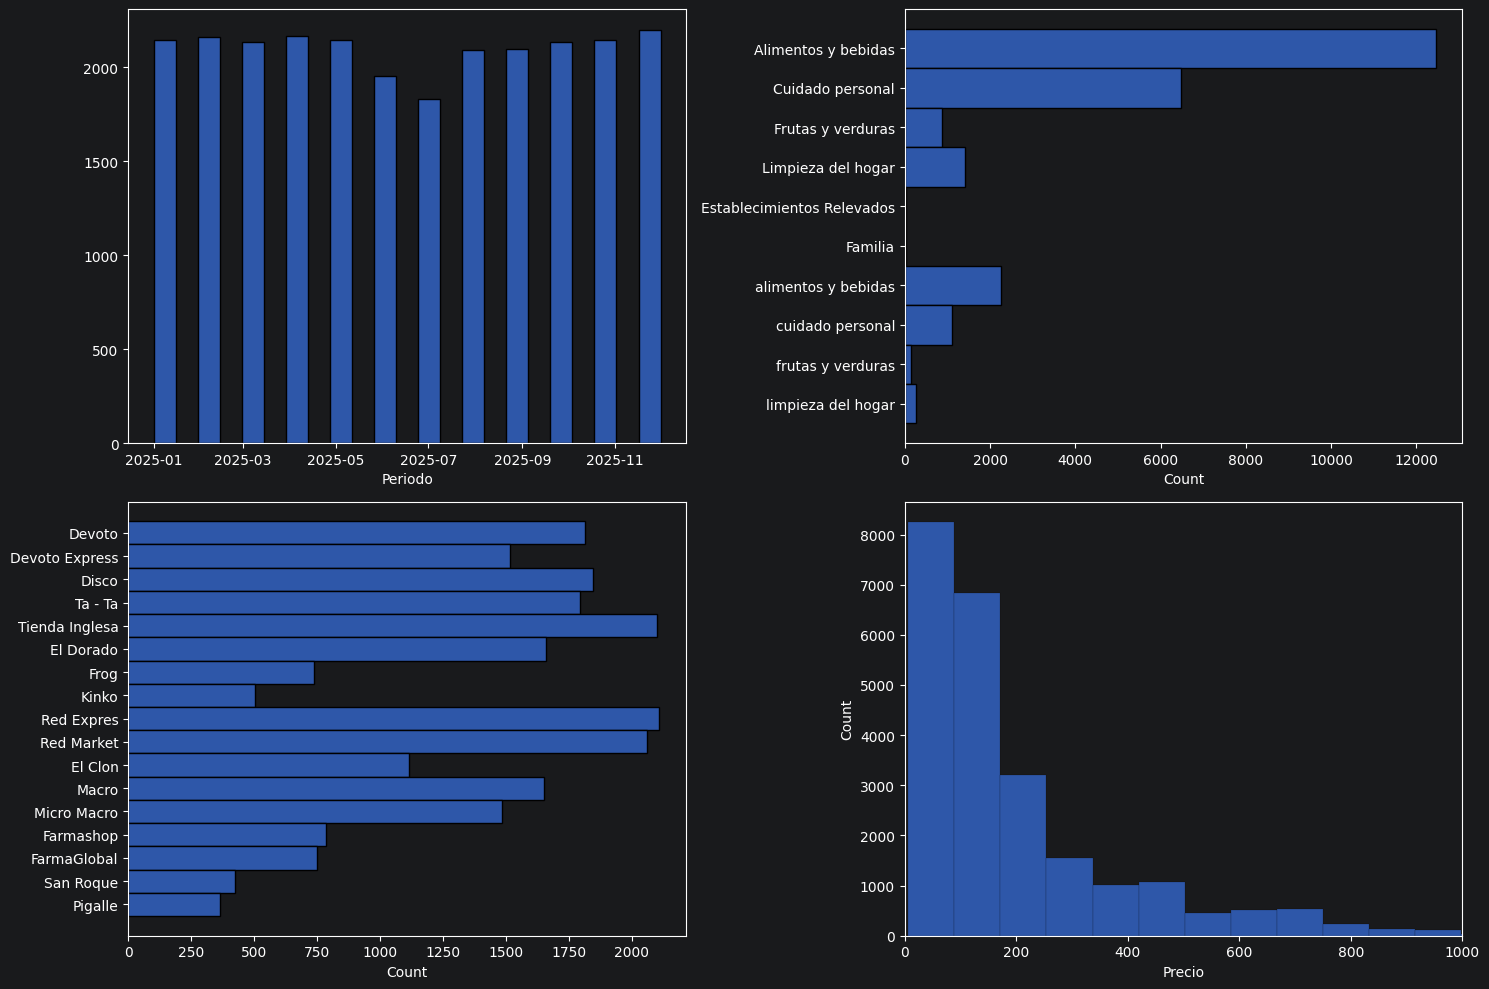

In [65]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(ax=axis[0, 0], data=df, x="Periodo").set(ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, y="Grupo").set(ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, y="Super").set(ylabel=None)
sns.histplot(ax=axis[1, 1], data=df, x="Precio").set_xlim(0, 1000)

plt.tight_layout()
plt.show()


>### Observación
> - Se detectó un valor que no aporta datos en Grupo. El valor <b>Establecimientos Relevados</b> no aporta valor al objetivo del presente proyecto. Vamos a listar los datos y posteriormente eliminar las filas vinculadas. Un total de 68 filas serán eliminadas del dataframe.
> - Se detecto duplicidad en Grupo ya que hay valores que respresentan lo mismo, difieren que estan en mayúsculas y minúsculas. Se unificaran usando el formato `Title`.
> - Se observan valores de `Precio` que no estan acordes al valor real. Realizaremos un analisis y depuración de los datos que estén fuera de un rango coherente para los productos referenciados.

### Depuración de datos:
Por valores de `Prodducto` incorrectos:
>- Eliminar las filas de Producto = Establecimiento relevado
>- Eliminar las filas de Producto = Familia

In [153]:
# Visualizar los datos de Grupo con valor igual a Establecimientos Relevados
# df = df_unico_tipo_dato_ok.copy(deep=True)
filtro_valores = ['Establecimientos Relevados', 'Familia']
data_filtrada = df[df['Grupo'].isin(filtro_valores)]

# mostrar los datos a eliminar
data_filtrada
#


,Periodo,Grupo,Producto,Super,Precio


In [154]:
# Eliminar los datos de Grupo con valor igual a Establecimientos Relevados
filtro_valores = ['Establecimientos Relevados', 'Familia']
df = df[~df['Grupo'].isin(filtro_valores)]

# Borramos las referencias a los indices
df = df.drop(df[df['Producto'] == 'Establecimientos Relevados'].index)
df = df.drop(df[df['Producto'] == 'Familia'].index)


In [155]:
# Verificando los datos fueron eliminados permanentemente
data_filtrada = df.query('Producto == "Establecimientos Relevados" | Producto == "Familia"')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio


In [71]:
# Unificar el formato de los valores para Grupo
df['Grupo'] = df['Grupo'].str.title()

In [157]:
# Realizamos un respaldo de dataframe
# df_unico_tipo_dato_ok.csv
# - no tiene datos duplicados
# - Se eliminaron las filas de productos = Establecimientos Relevados
# - Se eliminaron las filas de productos = Familia

# respaldo en archivo csv
df.to_csv('../data/processed/df_unico_productos_depurados.csv', index=False)

# respaldo en memoria
df_unico_tipo_dato_ok = df.copy(deep=True)

In [16]:
# restarurar el dataframe de df_unico_productos_depurados
#df = pd.read_csv("../data/processed/df_unico_productos_depurados.csv")
# respaldo en memoria
#df_unico_tipo_dato_ok = df.copy(deep=True)

#formateamos la columna de periodo a tipo fecha
#df['Periodo'] = pd.to_datetime(df['Periodo'], format="%Y-%m-%d", errors="raise")


### Depuración de datos:
Por valores de `Precio` incorrectos:
>- Eliminar las filas con `Precios` > 900 con `Grupo` = Alimentos Y Bebidas
>- Eliminar las filas con `Precios` > 1500


In [4]:
# Detección de precios atípicos empleando outliers

Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Precio'] < lower_bound) | (df['Precio'] > upper_bound)]

print("Outliers:\n")
outliers

Outliers:



,Periodo,Grupo,Producto,Super,Precio
339,2025-04-01,Alimentos Y Bebidas,Chorizos mezcla sueltos - Cattivelli - Extra 1...,Devoto,648.00
340,2025-04-01,Alimentos Y Bebidas,Chorizos mezcla sueltos - Cattivelli - Extra 1...,Devoto Express,648.00
341,2025-04-01,Alimentos Y Bebidas,Chorizos mezcla sueltos - Cattivelli - Extra 1...,Disco,648.00
342,2025-04-01,Alimentos Y Bebidas,Chorizos mezcla sueltos - Cattivelli - Extra 1...,Macro,571.74
343,2025-04-01,Alimentos Y Bebidas,Chorizos mezcla sueltos - Cattivelli - Extra 1...,Micro Macro,571.74
...,...,...,...,...,...
24628,2025-10-01,Frutas Y Verduras,"Manzana Red Deliciosa, 1 kg.",Macro,1469.00
24629,2025-03-01,Alimentos Y Bebidas,Sal fina yodada fluorada Sek Paquete 500 grs.,Disco,640.00
24630,2025-02-01,Cuidado Personal,Curitas Ready Plast 8 us.,Frog,500.00
24631,2025-12-01,Cuidado Personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.00


In [5]:
# Eliminar de los datos con precios fuera de rango
df = df[~((df['Precio'] < lower_bound) | (df['Precio'] > upper_bound))]

# Borramos las referencias a los indices
df = df.drop(df[(df['Precio'] < lower_bound) | (df['Precio'] > upper_bound)].index)

In [7]:
# Verificamos los registros eliminados
data_filtrada = df[((df['Precio'] < lower_bound) | (df['Precio'] > upper_bound))]
#data_filtrada = df.query('Precio < 1')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio


In [17]:
# verificamos el cambio en el tipo de dato de Periodo
#df.describe(include='all')

df.info()

<class 'pandas.DataFrame'>
Index: 22411 entries, 0 to 24624
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Periodo   22411 non-null  datetime64[us]
 1   Grupo     22411 non-null  str           
 2   Producto  22411 non-null  str           
 3   Super     20150 non-null  str           
 4   Precio    21511 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.5 MB


### Regeneramos los histogramas
Constatamos que los histogramas sean correctos y que no hayan valores fuera de rango.


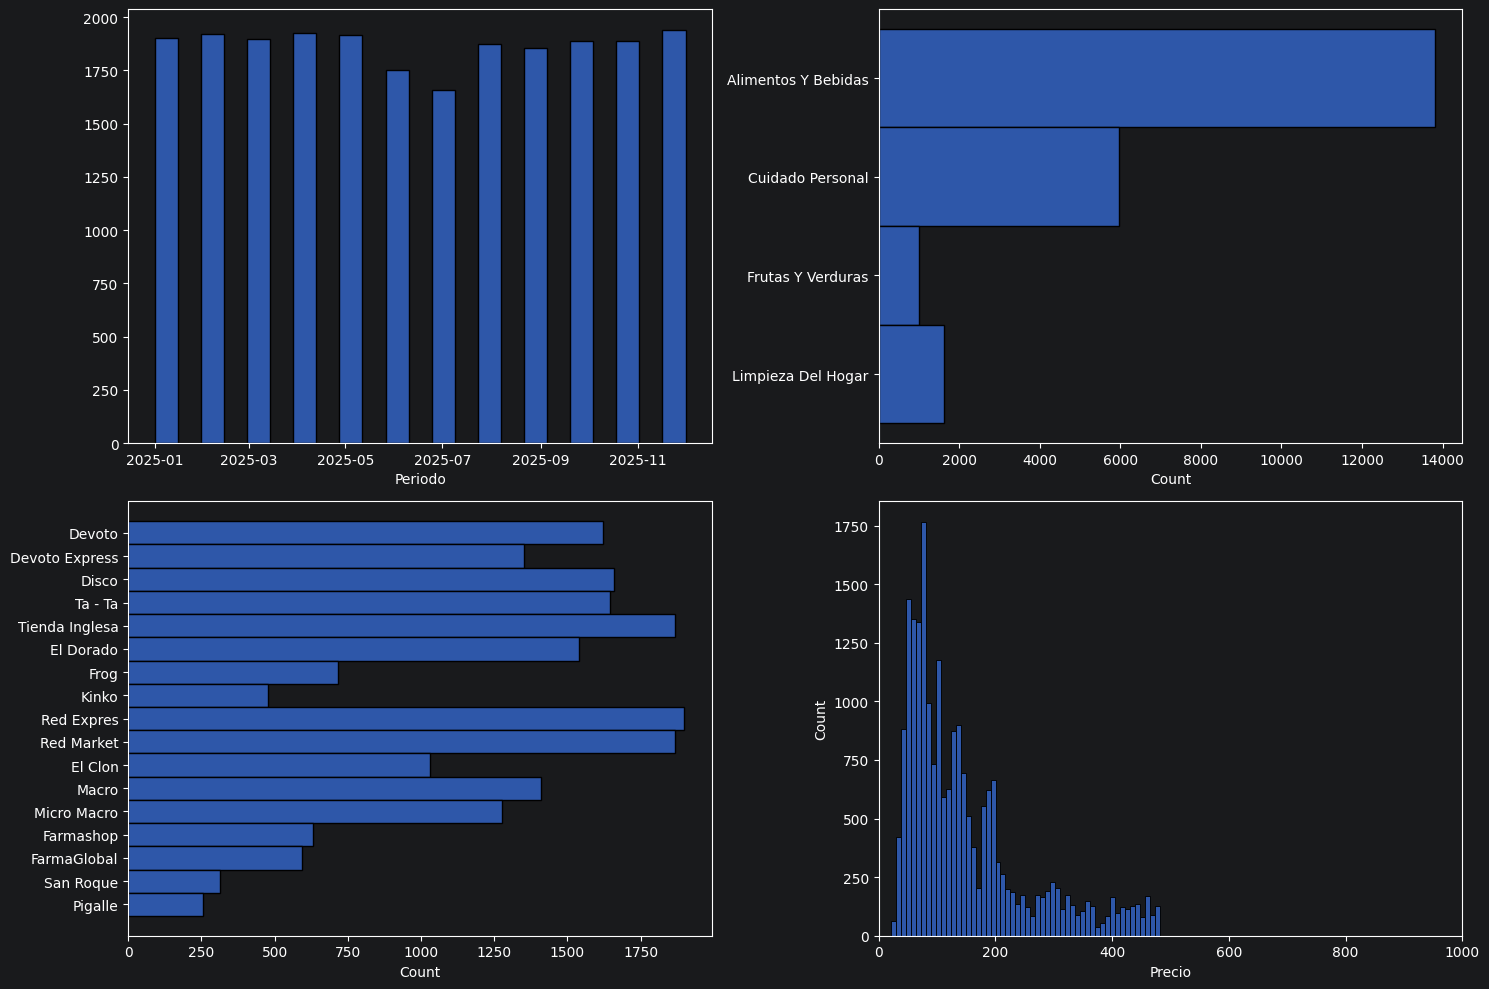

In [18]:
# Regeneramos los histogramas con los valores corregidos
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(ax=axis[0, 0], data=df, x="Periodo").set(ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, y="Grupo").set(ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, y="Super").set(ylabel=None)
sns.histplot(ax=axis[1, 1], data=df, x="Precio").set_xlim(0, 1000)

plt.tight_layout()
plt.show()


In [19]:
# Realizamos un respaldo de dataframe
# df_unico_productos_precios_depurados.csv
# - no tiene datos duplicados
# - Se eliminaron las filas de productos = Establecimientos Relevados
# - Se eliminaron las filas de productos = Familia
# - Se eliminaron las filas de precios > 900 en Grupo = Alimentos y Bebidas
# - Se eliminaron las filas de precios > 1500

# respaldo en archivo csv
df.to_csv('../data/processed/df_unico_productos_precios_depurados.csv', index=False)

# respaldo en memoria
df_unico_tipo_dato_ok = df.copy(deep=True)

### Depuración de datos:
Un detalle que limita el analisis de los datos tiene ver que la `Producto` es un texto que guarda datos de los productos, entre los cuales podemos mencionar:
>- Nombre del producto
>- Marca
>- Presentación

Para extraer estos valores, se elaboró un script en Python que permite procesar los datos de la columna `Producto` y extraer los atributos de los productos.

El script esta en la carpeta utils y se llama `extraer_producto_marca_presentacion.py`

Este script genera un archivo cvs de productos con los atributos de los productos y se adicionó columnas que permiten definir la canasta familiar, en base a la familia de productos y cantidad del producto..




In [58]:
# A continuación vamos a crear un dataframe unificado con los datos depurados y los atributos de los productos extraídos.
df_precios = []
df_productos = []
try:
    # Cargamos el dataframe del histórico de precios
    df_precios = pd.read_csv("../data/processed/df_unico_productos_precios_depurados.csv")

    # Cargamos el dataframe del mapa de precios
    df_productos = pd.read_csv("../data/processed/mapa_productos_extraidos_canasta.csv", sep=";", encoding="iso-8859-1")
except ValueError as e:
    print(f"Caught a ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
#finally:
    #print(df_productos)

In [74]:
# Creando un nuevo dataframe con df_productos + df_precios

df = df_precios.merge(df_productos[['Producto', 'tipo_producto', 'marca', 'presentacion', 'tipo_envoltorio','presentacion_valor', 'presentacion_unidad', 'nombre_comercial', 'canasta_producto', 'canasta_cantidad']], on='Producto', how='left')

df_precios['Periodo'] = pd.to_datetime(df['Periodo'], format="%Y-%m-%d", errors="raise")

# Verificamos nulos
df.isna().sum()
#df.info()

Periodo                    0
Grupo                      0
Producto                   0
Super                   2261
Precio                   900
tipo_producto              0
marca                      0
presentacion               0
tipo_envoltorio            0
presentacion_valor         0
presentacion_unidad        0
nombre_comercial           0
canasta_producto       16413
canasta_cantidad       16413
dtype: int64

In [75]:
# Verificando los datos fueron eliminados permanentemente
data_filtrada = df[df['Precio'].isnull()]
#data_filtrada = df.query("Precio.isnull()", engine='python')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio,tipo_producto,marca,presentacion,tipo_envoltorio,presentacion_valor,presentacion_unidad,nombre_comercial,canasta_producto,canasta_cantidad
1124,2025-04-01,Cuidado Personal,"Crema Facial Revitalift Filler Dia, 50 ml.",El Dorado,NaN,Crema facial,Revitalift,Envase 50 ml.,Envase,50.00,ML,Crema facial Filler Dia,NaN,NaN
1125,2025-04-01,Cuidado Personal,"Crema Facial Revitalift Filler Dia, 50 ml.",FarmaGlobal,NaN,Crema facial,Revitalift,Envase 50 ml.,Envase,50.00,ML,Crema facial Filler Dia,NaN,NaN
1304,2025-04-01,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",Devoto,NaN,Panales para ninos,Babysec,Empaque 48 Unidades,Empaque,48.00,UNIDADES,Panales para ninos Premium Extra Extra Grande,NaN,NaN
1305,2025-04-01,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",Devoto Express,NaN,Panales para ninos,Babysec,Empaque 48 Unidades,Empaque,48.00,UNIDADES,Panales para ninos Premium Extra Extra Grande,NaN,NaN
1306,2025-04-01,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",Disco,NaN,Panales para ninos,Babysec,Empaque 48 Unidades,Empaque,48.00,UNIDADES,Panales para ninos Premium Extra Extra Grande,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22366,2025-03-01,Cuidado Personal,"Perfume Casapueblo 24 Heures Blue Edt, 100 ml.",Red Expres,NaN,Perfume,Casapueblo,Envase 100 ml.,Envase,100.00,ML,Perfume 24 Heures Blue Edt,NaN,NaN
22367,2025-10-01,Alimentos Y Bebidas,Pescado fresco bifes de merluz - sin marca 1 kg.,Disco,NaN,Pescado,Genérico,1 kg.,Para Empaquetar,1.00,KG,Pescado Merluza en bifes,NaN,NaN
22368,2025-11-01,Alimentos Y Bebidas,"Agua mineral sin gas(bidón) Salus 6,25lts",Ta - Ta,NaN,Agua,Salus,"Envase 6,25lts",Envase,6.25,LT,Agua mineral sin gas bidon,NaN,NaN
22369,2025-04-01,Cuidado Personal,"Champú Pantene, 400 ml.",El Dorado,NaN,Champu,Pantene,Envase 400 ml.,Envase,400.00,ML,Champu,NaN,NaN


In [76]:
# Eliminar de las filas de Precios nulos
df = df[~(df['Precio'].isnull())]

# Borramos las referencias a los indices
df = df.drop(df[df['Precio'].isnull()].index)

# Verificamos nulos
df.isna().sum()

Periodo                    0
Grupo                      0
Producto                   0
Super                   2201
Precio                     0
tipo_producto              0
marca                      0
presentacion               0
tipo_envoltorio            0
presentacion_valor         0
presentacion_unidad        0
nombre_comercial           0
canasta_producto       15611
canasta_cantidad       15611
dtype: int64

In [78]:
# Realizamos un respaldo de dataframe
# df_unico_productos_precios_depurados.csv + mapa_productos_extraidos_canasta.csv

df.to_csv("../data/processed/df_precios_depurado_enriquecido.csv", index=False, encoding="utf-8-sig", sep=";")

In [97]:
# restarurar el dataframe de precios depurado enriquecido
df = pd.read_csv("../data/processed/df_precios_depurado_enriquecido.csv",sep=";",encoding="utf-8-sig")

df['Periodo'] = pd.to_datetime(df['Periodo'], format="%Y-%m-%d", errors="raise")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21511 entries, 0 to 21510
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Periodo              21511 non-null  datetime64[us]
 1   Grupo                21511 non-null  str           
 2   Producto             21511 non-null  str           
 3   Super                19310 non-null  str           
 4   Precio               21511 non-null  float64       
 5   tipo_producto        21511 non-null  str           
 6   marca                21511 non-null  str           
 7   presentacion         21511 non-null  str           
 8   tipo_envoltorio      21511 non-null  str           
 9   presentacion_valor   21511 non-null  float64       
 10  presentacion_unidad  21511 non-null  str           
 11  nombre_comercial     21511 non-null  str           
 12  canasta_producto     5900 non-null   float64       
 13  canasta_cantidad     5900 non-null   float

In [98]:
df.isna().sum()

Periodo                    0
Grupo                      0
Producto                   0
Super                   2201
Precio                     0
tipo_producto              0
marca                      0
presentacion               0
tipo_envoltorio            0
presentacion_valor         0
presentacion_unidad        0
nombre_comercial           0
canasta_producto       15611
canasta_cantidad       15611
dtype: int64

In [99]:
df.groupby(["Grupo", "tipo_producto", "marca", "presentacion", "nombre_comercial"])["Precio"].agg(
    precio_promedio="mean",
    precio_mediano="median",
    precio_minimo="min",
    precio_maximo="max",
    observaciones="count"
).reset_index()

,Grupo,tipo_producto,marca,presentacion,nombre_comercial,precio_promedio,precio_mediano,precio_minimo,precio_maximo,observaciones
0,Alimentos Y Bebidas,Aceite,Condesa,Envase 900 cc,Aceite de soja,72.311905,71.00,63.0,91.00,126
1,Alimentos Y Bebidas,Aceite,Delicia,Envase 900 cc,Aceite de maiz,122.852857,127.00,98.0,149.00,147
2,Alimentos Y Bebidas,Aceite,Devoto,Envase 900 cc,Aceite de girasol,84.000000,79.00,79.0,99.00,4
3,Alimentos Y Bebidas,Aceite,Marca Propia,Envase 900 cc,Aceite de girasol,93.033333,98.00,79.0,103.00,30
4,Alimentos Y Bebidas,Aceite,Marcas Propias,Envase 900 cc,Aceite de girasol,87.250000,82.00,79.0,99.00,16
...,...,...,...,...,...,...,...,...,...,...
293,Limpieza Del Hogar,Jabon para ropa,Nevex,Empaque Unidad 200 grs.,Jabon para ropa en barra,60.850000,60.00,40.0,72.20,118
294,Limpieza Del Hogar,Jabon para ropa,Primor,Empaque Unidad 200 grs.,Jabon para ropa en barra,36.942105,36.00,35.0,44.90,19
295,Limpieza Del Hogar,Jabon para ropa,Primor,Empaque Unidad 300 grs.,Jabon para ropa en barra,41.942157,39.00,30.0,300.00,102
296,Limpieza Del Hogar,Jabon para ropa,Skip,Empaque 800 grs.,Jabon para ropa en polvo,152.881364,152.00,117.0,175.51,110


#### 5.2) Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos (enteros, fracciones, decimales, negativos, etc.) en un rango infinito.

A los efectos la variable 'Precios' es la única columna con valores numéricos, Haremos un ejercicio contemplando los valores de los precios según el grupo o familia de producto.

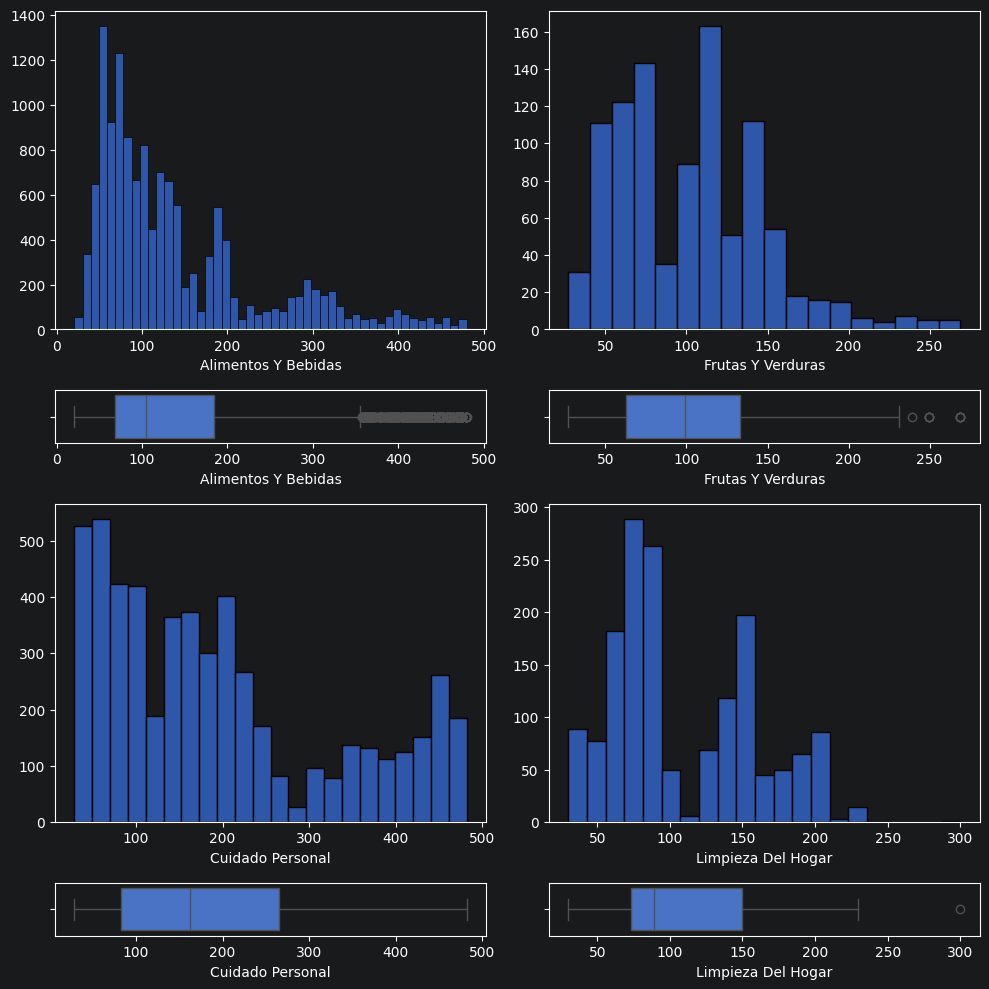

In [100]:
# Generando histogramas de grupos por precios
fig, axis = plt.subplots(4, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

sns.histplot(ax=axis[0, 0], data=df[(df['Grupo'] == 'Alimentos Y Bebidas')], x="Precio").set(xlabel="Alimentos Y Bebidas", ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df[(df['Grupo'] == 'Alimentos Y Bebidas')], x="Precio").set(xlabel="Alimentos Y Bebidas", ylabel=None)
sns.histplot(ax=axis[0, 1], data=df[(df['Grupo'] == 'Frutas Y Verduras')], x="Precio").set(xlabel="Frutas Y Verduras", ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df[(df['Grupo'] == 'Frutas Y Verduras')], x="Precio").set(xlabel="Frutas Y Verduras", ylabel=None)
sns.histplot(ax=axis[2, 0], data=df[(df['Grupo'] == 'Cuidado Personal')], x="Precio").set(xlabel="Cuidado Personal", ylabel=None)
sns.boxplot(ax=axis[3, 0], data=df[(df['Grupo'] == 'Cuidado Personal')], x="Precio").set(xlabel="Cuidado Personal", ylabel=None)
sns.histplot(ax=axis[2, 1], data=df[(df['Grupo'] == 'Limpieza Del Hogar')], x="Precio").set(xlabel="Limpieza Del Hogar", ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df[(df['Grupo'] == 'Limpieza Del Hogar')], x="Precio").set(xlabel="Limpieza Del Hogar", ylabel=None)

plt.tight_layout()
plt.show()


> #### Observaciones:
>
> - De la visualización resultante podemos observar que las colecciones de datos por grupos de producto cuentan con valores atípicos.
> - Las distribuciones tienen asimetría, la primera totalmente sesgada hacia la izquierda, donde la media es inferior a la moda y la otra con menor tendencia.
> - Se puede concluir que agrupar por familias de productos no genera un aporte significativo. En este punto valdria la pena intentar este mismo procedimiento con tipo de producto. Sin embargo para llevar acabo esta opcion debemos hacer un tratamiento sobre la columna `Producto` para geerar las siguientes columnas:
>> - Tipo de Producto
>> - Marca
>> - Presentacion

### 5.3) Análisis de Variables Multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Así, si quisiéramos eliminar una variable debido a una alta cantidad de valores nulos o ciertos outliers, es necesario antes aplicar este proceso para asegurar que la eliminación de ciertos valores no son críticos para la supervivencia de un pasajero.

#### Observaciones:
Teniendo en cuenta la naturaleza de esta técnica, no vemos necesario aplicarla dado que el conjunto de datos tiene la minima cantidad de columnas o variables para modelar un escenario de valores de toma de decisiones para la compra de productos.

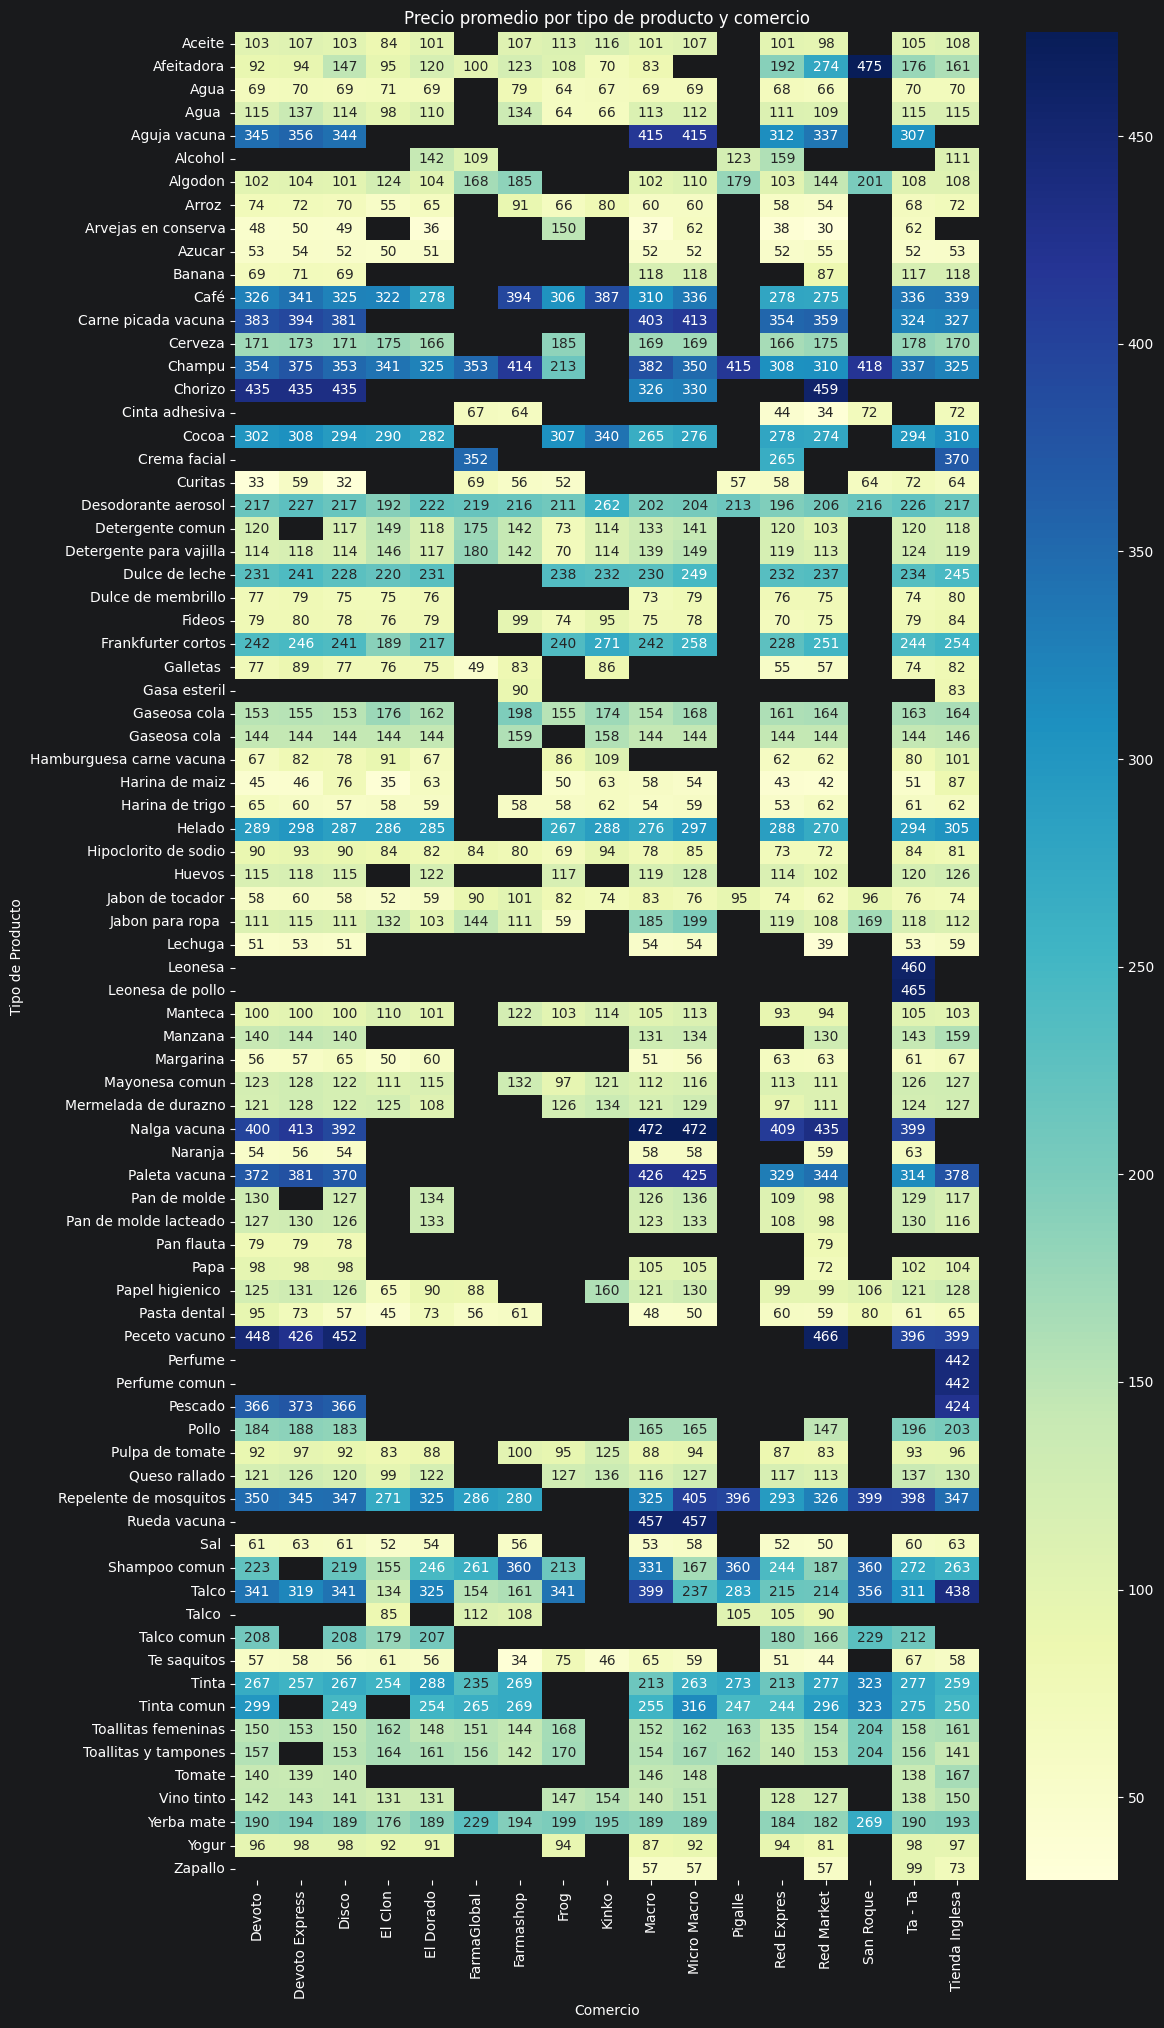

In [101]:
tabla_grupo_comercio = df.pivot_table(
    index="tipo_producto",
    columns="Super",
    values="Precio",
    aggfunc="mean"
)

plt.figure(figsize=(12, 24))
sns.heatmap(tabla_grupo_comercio, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Precio promedio por tipo de producto y comercio")
plt.xlabel("Comercio")
plt.ylabel("Tipo de Producto")
plt.show()

### Observaciones:
Esta alternativa sirve para comparar qué comercios son más costosos o económicos según la familia del producto.
>- Comercios con precios sistemáticamente altos.
>- Grupos de productos con mayor diferencia entre comercios.
>- Posibles estrategias para recomendar dónde comprar cada categoría.

#### Análisis categórico-categórico

Cuando las dos variables que se comparan tienen datos categóricos, se dice que el análisis es categórico-categórico. Para comparar dos columnas numéricas se utilizan histogramas y combinaciones.


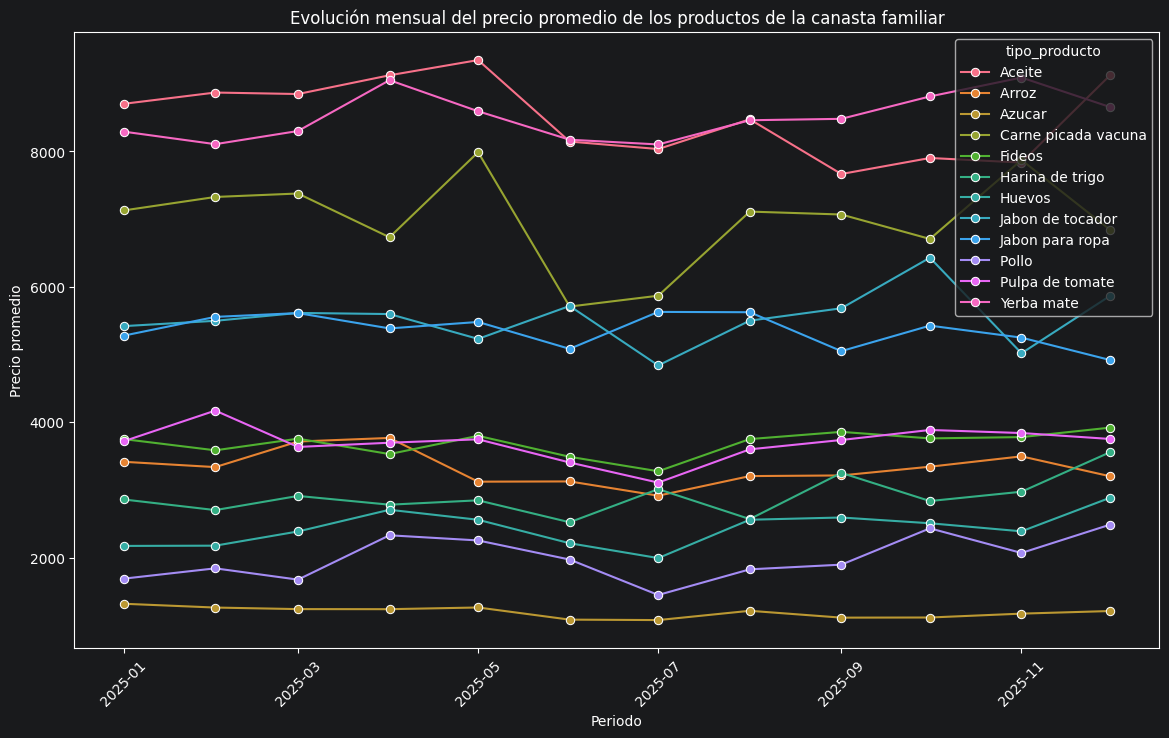

In [104]:
precio_mensual_grupo = (
    df[(df['canasta_producto'] == 1)].groupby(["Periodo", "tipo_producto"])["Precio"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=precio_mensual_grupo,
    x="Periodo",
    y="Precio",
    hue="tipo_producto",
    marker="o"
)

plt.title("Evolución mensual del precio promedio de los productos de la canasta familiar")
plt.xlabel("Periodo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

### Observaciones:
Esta alternativa sirve para comparar la evolución de los precios de los productos de la canasta familiar. A partir de allí podemos interpretar:
>- Grupos con tendencia inflacionaria.
>- Categorías estables.
>- Cambios bruscos que requieren validación.
>- Estacionalidad de ciertos productos.
>- Este análisis es útil para que el agente pueda responder preguntas como:
>>- ¿Qué grupo de productos aumentó más en los últimos meses?

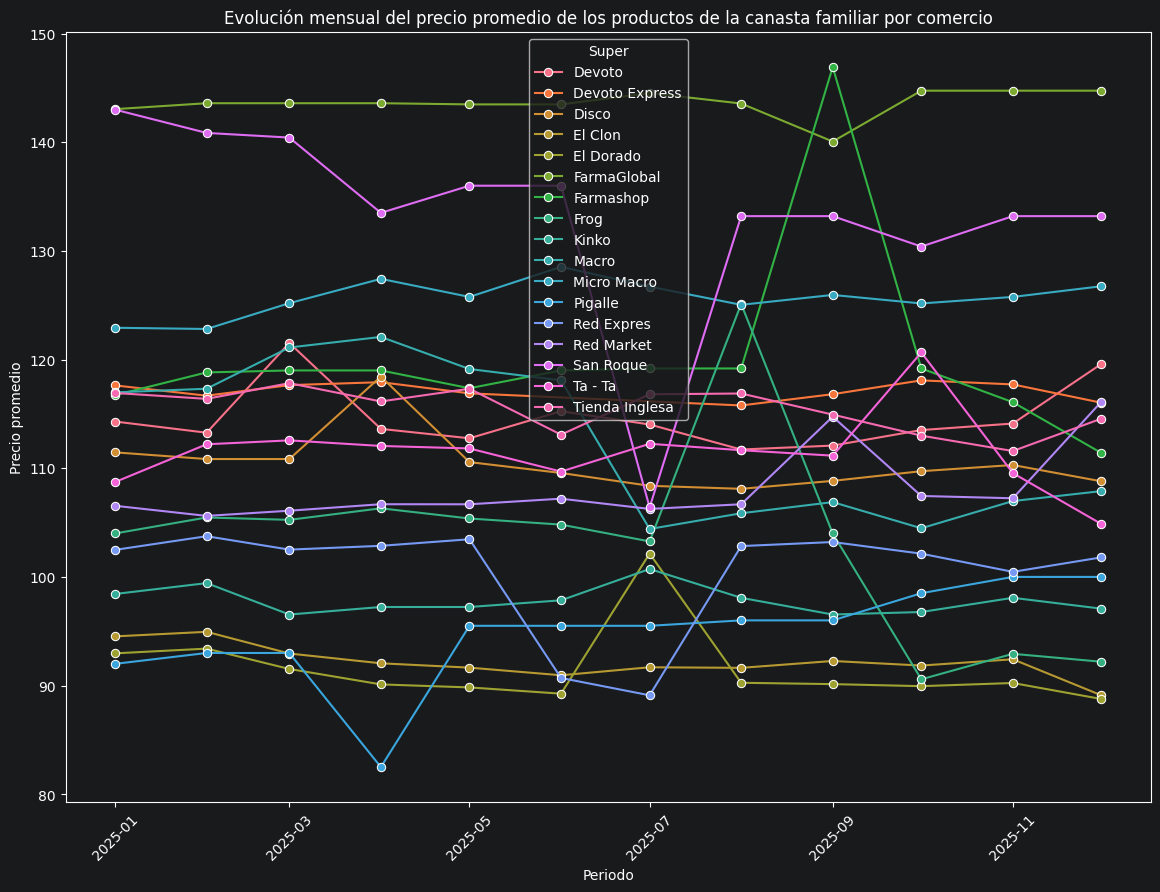

In [105]:
precio_mensual_comercio = (
    df[(df['canasta_producto'] == 1)].groupby(["Periodo", "Super"])["Precio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 10))
sns.lineplot(
    data=precio_mensual_comercio,
    x="Periodo",
    y="Precio",
    hue="Super",
    marker="o"
)

plt.title("Evolución mensual del precio promedio de los productos de la canasta familiar por comercio")
plt.xlabel("Periodo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

### Observaciones:
Esta alternativa sirve para comparar la evolución de los precios de los productos de la canasta familiar por cadena. A partir de allí podemos interpretar:
>- Cadenas que ofrecen mejores precios para la canasta familiar
>- Varicion de precios de la canasta familiar por cadenas

In [123]:
fig = px.histogram(
    df,
    x='Precio',
    template="seaborn",
    title="Histograma de precios",
)

fig.show()

In [153]:
fig = px.box(
    df[df['canasta_producto'] == 1].reset_index(),
    x="Grupo",
    y="Precio",
    color="Super",
    title="Boxplot de precios de productos canasta por comercio",
    template="seaborn",
    height=550
)
fig.show()

### Observaciones:
Este gráfico nos sirve para analizar dispersión, rangos y posibles precios atípicos.. A partir de allí podemos interpretar:
>- Grupos con mucha variabilidad.
>- Comercios con precios más dispersos.
>- Productos posiblemente mal registrados.
>- Categorías difíciles de usar como referencia única.

Un grupo con mucha dispersión puede requerir más depuración, porque puede mezclar productos muy distintos.

In [148]:
precio_mensual_comercio = (
    df[(df['tipo_producto'] == 'Aceite')].groupby(["Periodo", "nombre_comercial"])["Precio"]
    .mean()
    .reset_index()
)

fig = px.line(
    precio_mensual_comercio,
    x='Periodo',
    y='Precio',
    color='nombre_comercial',
    markers=True,
    template="seaborn",
    height=500,
    title="Tendencia de precios promedio de Aceite por tipo de aceite"
)
fig.show()

In [149]:
precio_mensual_comercio = (
    df[(df['tipo_producto'] == 'Aceite')].groupby(["Periodo", "marca"])["Precio"]
    .mean()
    .reset_index()
)

fig = px.line(
    precio_mensual_comercio,
    x='Periodo',
    y='Precio',
    color='marca',
    markers=True,
    template="seaborn",
    height=500,
    title="Tendencia de precios promedio de Aceite por tipo de aceite"
)
fig.show()

### Observaciones:
Esta alternativa sirve para comparar la evolución anual de los precios de un producto segmentado por marca. A partir de allí podemos interpretar:
>- Marcas que ofrecen mejores precios por productos
>- Variación de precios de un producto por marca

In [4]:
# restarurar el dataframe de precios depurado enriquecido
#df = pd.read_csv("../data/processed/df_precios_depurado_enriquecido.csv", sep=";", encoding="utf-8-sig")

In [156]:
# Listado de Ranking de precios de productos agrupados por grupo, nombre comercial, marca y comercio

ranking_productos = df.copy()

ranking_productos["ranking_precio"] = (
    ranking_productos
    .groupby(["Periodo", "nombre_comercial", "marca", "Super"])["Precio"]
    .rank(method="dense", ascending=True)
)

productos_mas_baratos = ranking_productos[
    ranking_productos["ranking_precio"] == 1
].sort_values(["Periodo", "nombre_comercial", "marca"])

productos_mas_baratos[
    ["Periodo", "Grupo", "nombre_comercial", "marca", "Super","Precio"]
]

,Periodo,Grupo,nombre_comercial,marca,Super,Precio
4908,2025-01-01,Alimentos Y Bebidas,Aceite de girasol,Marca Propia,Devoto,99.0
4909,2025-01-01,Alimentos Y Bebidas,Aceite de girasol,Marca Propia,Devoto Express,99.0
4910,2025-01-01,Alimentos Y Bebidas,Aceite de girasol,Marca Propia,Disco,99.0
4911,2025-01-01,Alimentos Y Bebidas,Aceite de girasol,Marca Propia,Ta - Ta,95.0
4912,2025-01-01,Alimentos Y Bebidas,Aceite de girasol,Marca Propia,Tienda Inglesa,103.0
...,...,...,...,...,...,...
4783,2025-12-01,Frutas Y Verduras,Zapallo Calabacin,Genérico,Macro,79.9
4784,2025-12-01,Frutas Y Verduras,Zapallo Calabacin,Genérico,Micro Macro,79.9
4785,2025-12-01,Frutas Y Verduras,Zapallo Calabacin,Genérico,Red Market,78.0
4786,2025-12-01,Frutas Y Verduras,Zapallo Criollo,Genérico,Red Market,63.0


### Análisis numérico-categórico
El análisis numérico-categórico permite estudiar cómo se comporta una variable numérica según las categorías de otra variable. En este dataset, la variable numérica principal es Precio, mientras que las variables categóricas son `Periodo`, `Grupo`, `Producto` y `Super`.

Este análisis permite responder preguntas como:

>- qué grupos de productos tienen precios más altos,
>- qué supermercados presentan precios promedio más elevados,
>- cómo varían los precios según el período,
>- y qué productos concentran los precios más altos.

Para este tipo de análisis no se calculan correlaciones tradicionales, ya que las variables categóricas no son numéricas. En su lugar, se utilizan agrupaciones, medidas estadísticas y gráficos como boxplots o barras comparativas.

In [160]:
# Estadísticas de precios por tipo de producto
df.groupby("tipo_producto")["Precio"].describe()


,count,mean,std,min,25%,50%,75%,max
tipo_producto,,,,,,,,
Aceite,991.0,102.972432,23.735377,60.0,81.00,99.000,123.000,166.00
Afeitadora,189.0,148.499365,116.913217,49.9,92.00,100.110,127.000,480.00
Agua,735.0,69.352735,7.615450,54.0,63.00,70.000,76.000,84.00
Agua,416.0,113.582115,31.198732,54.0,76.00,128.995,137.000,154.00
Aguja vacuna,190.0,356.357895,54.080489,279.0,301.25,352.000,401.125,459.00
...,...,...,...,...,...,...,...,...
Tomate,163.0,145.759202,55.476962,64.9,99.00,132.900,189.000,269.00
Vino tinto,383.0,139.045587,14.377037,107.0,130.00,139.000,150.000,166.81
Yerba mate,531.0,192.258493,18.077578,149.0,185.00,191.000,194.900,269.00


In [161]:
# Estadísticas precios por nombre comercial
df.groupby("nombre_comercial")["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
nombre_comercial,,,,,,,,
Aceite de girasol,474.0,102.659515,14.140714,75.0,95.00,99.00,115.00,132.00
Aceite de maiz,265.0,130.243283,14.018107,98.0,124.28,130.00,140.00,166.00
Aceite de soja,252.0,74.883333,7.812909,60.0,69.00,74.45,79.25,91.00
Afeitadora Mach 3 Dispenser X2,20.0,452.250000,26.221476,399.0,429.75,451.50,476.00,480.00
Afeitadora Piel Delicada X 1,143.0,106.418042,28.924593,49.9,92.00,99.90,109.00,191.00
...,...,...,...,...,...,...,...,...
Yogur Bio Top,116.0,96.075948,6.852586,80.0,90.09,95.20,103.00,109.00
Yogur Bio Yogur,30.0,87.680000,14.251301,57.5,89.90,89.90,98.00,98.00
Yogur semi descremado,38.0,92.528947,9.720302,57.0,89.90,94.75,98.00,106.00


## Paso 6: Análisis univariante
En este paso se realiza un análisis univariante, es decir, se estudia cada variable de forma individual.

El objetivo es comprender la distribución y frecuencia de las principales variables del dataset antes de analizar relaciones entre ellas.

Para este trabajo se analizarán:

>- `Super`: cadena o establecimiento donde se registró el producto.
>- `Grupo`: categoría o rubro comercial del producto.
>- `Precio`: variable numérica principal del análisis.
>- `marca`: variable texto principal del análisis.
>- `tipo_producto`: variable texto principal del análisis.
>- `nombre comercial`: variable texto principal del análisis.

Este análisis permite conocer la composición general de la base y detectar patrones iniciales en los datos.

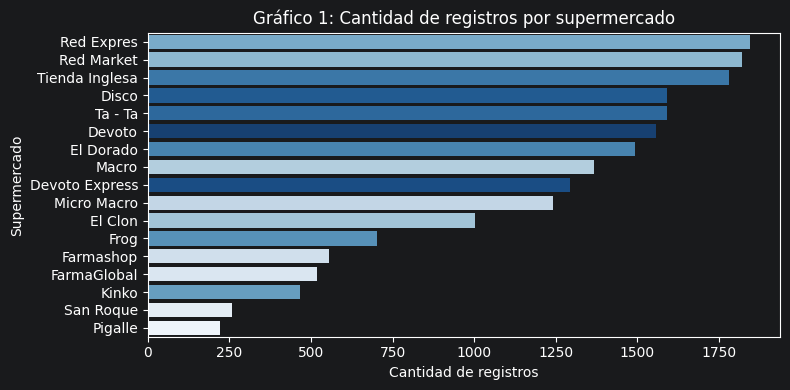

Cantidad de registros por supermercado:
Super
Red Expres        1845
Red Market        1822
Tienda Inglesa    1782
Disco             1591
Ta - Ta           1590
Devoto            1557
El Dorado         1493
Macro             1366
Devoto Express    1294
Micro Macro       1243
El Clon           1004
Frog               702
Farmashop          556
FarmaGlobal        519
Kinko              467
San Roque          259
Pigalle            220
Name: count, dtype: int64


In [168]:
# PASO 6: ANÁLISIS UNIVARIANTE

# 6.1 DISTRIBUCIÓN POR SUPERMERCADO

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    y="Super",
    order=df["Super"].value_counts().index,
    hue="Super",
    palette="Blues_r",
    legend=False
)

plt.title("Gráfico 1: Cantidad de registros por supermercado")
plt.xlabel("Cantidad de registros")
plt.ylabel("Supermercado")
plt.tight_layout()
plt.show()

print("Cantidad de registros por supermercado:")
print(df["Super"].value_counts())

### Interpretación de la variable Super

Esta información es importante porque permite identificar si la base está equilibrada entre cadenas o si algunos supermercados tienen mayor representación que otros. En realidad hemos observado en otras gráficas que los productos por supermercado varían de acuerdo a cierta preferencia de distribución de los mismos. Por ejemplo, el Clon no comercializa verduras mientras que el El Dorado si, sin embargo a nivel de competitividad de productos, el aceite en el clon es mas económico que en El Dorado.

Una mayor cantidad de registros no significa necesariamente que un supermercado sea más grande o más barato, sino que dentro del dataset hay más observaciones disponibles para esa cadena.

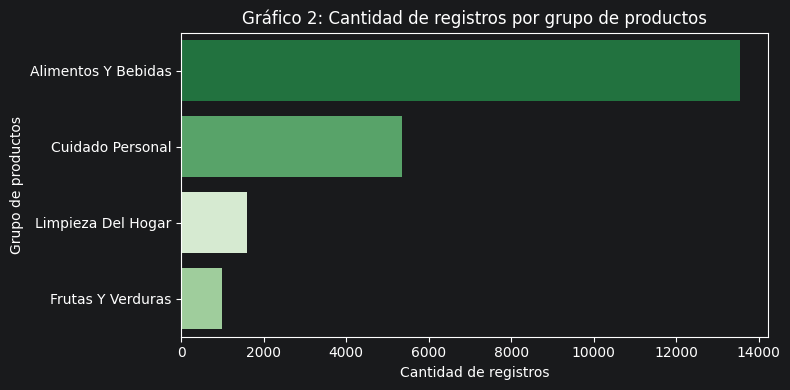

Cantidad de registros por grupo de productos:
Grupo
Alimentos Y Bebidas    13560
Cuidado Personal        5360
Limpieza Del Hogar      1604
Frutas Y Verduras        987
Name: count, dtype: int64


In [174]:
# 6.2 DISTRIBUCIÓN POR GRUPO DE PRODUCTOS

plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    y="Grupo",
    order=df["Grupo"].value_counts().index,
    hue="Grupo",
    palette="Greens_r",
    legend=False
)

plt.title("Gráfico 2: Cantidad de registros por grupo de productos")
plt.xlabel("Cantidad de registros")
plt.ylabel("Grupo de productos")
plt.tight_layout()
plt.show()

print("Cantidad de registros por grupo de productos:")
print(df["Grupo"].value_counts())

### Interpretación de la variable Grupo
El gráfico muestra que la distribución de registros por grupo de producto no es uniforme.

El grupo con mayor presencia es Alimentos Y Bebidas, con 13.560 registros, seguido por Cuidado Personal, con 5.360 registros. Estos dos grupos concentran la mayor parte de la base, por lo que tienen un peso importante en los análisis generales.

En cambio, grupos como Limpieza Del Hogar y Frutas Y Verduras aparecen con una cantidad menor de registros.

Esto es importante porque los promedios generales de precio pueden estar influidos por los grupos más representados. Por lo tanto, no alcanza con analizar el precio global del dataset: también es necesario observar cómo se comportan los precios dentro de cada grupo de producto.

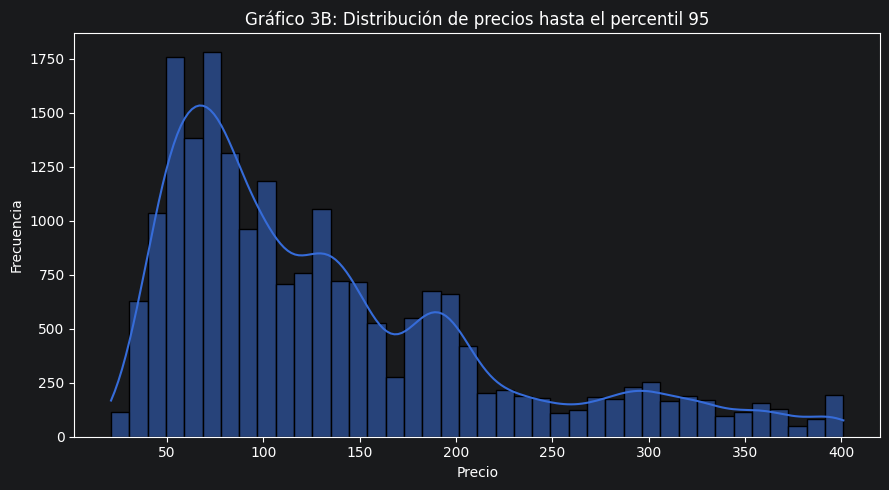

Percentil 95 de Precio: $401.10
Registros incluidos en esta visualización: 20436
Registros totales del dataset limpio: 21511
Cantidad de registros por grupo de productos:
Precio
75.0     308
59.0     274
79.0     273
69.0     270
99.0     235
        ... 
124.4      1
219.9      1
198.5      1
337.3      1
326.6      1
Name: count, Length: 1528, dtype: int64


In [175]:
# 6.3 DISTRIBUCIÓN POR GRUPO DE PRECIOS

percentil_95 = df["Precio"].quantile(0.95)

datos_precio_p95 = df[
    df["Precio"] <= percentil_95
]

plt.figure(figsize=(9, 5))

sns.histplot(
    data=datos_precio_p95,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 3B: Distribución de precios hasta el percentil 95")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Percentil 95 de Precio: ${percentil_95:.2f}")
print(f"Registros incluidos en esta visualización: {datos_precio_p95.shape[0]}")
print(f"Registros totales del dataset limpio: {df.shape[0]}")

print("Cantidad de registros por grupo de productos:")
print(df["Precio"].value_counts())
